# SAR Image Preprocessing

This notebook performs preprocessing on the Sen1Floods11 dataset before autoencoder-based image compression.

Steps:
1. Data Cleaning
2. Speckle Noise Reduction
3. Normalization
4. Image Resizing
5. Data Augmentation
6. Label Encoding
7. Train-Test Split

In [56]:
import os
import glob
import warnings
import numpy as np
import matplotlib.pyplot as plt
import rasterio

from scipy.ndimage import median_filter
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

In [57]:
BASE_PATH = "/content/drive/MyDrive/sar-project/data/raw/archive/v1.2"

SAR_PATH = os.path.join(
    BASE_PATH,
    "data/flood_events/HandLabeled/S1Hand"
)

MASK_PATH = os.path.join(
    BASE_PATH,
    "data/flood_events/HandLabeled/LabelHand"
)

print(SAR_PATH)
print(MASK_PATH)

/content/drive/MyDrive/sar-project/data/raw/archive/v1.2/data/flood_events/HandLabeled/S1Hand
/content/drive/MyDrive/sar-project/data/raw/archive/v1.2/data/flood_events/HandLabeled/LabelHand


In [58]:
sar_images = sorted(glob.glob(os.path.join(SAR_PATH, "*.tif")))
mask_images = sorted(glob.glob(os.path.join(MASK_PATH, "*.tif")))

print("SAR Images:", len(sar_images))
print("Mask Images:", len(mask_images))

SAR Images: 446
Mask Images: 448


In [60]:
#creating image mask pairs
sar_dict = {
    os.path.basename(f).replace("_S1Hand.tif", ""): f
    for f in sar_images
}

mask_dict = {
    os.path.basename(f).replace("_LabelHand.tif", ""): f
    for f in mask_images
}

common_keys = list(set(sar_dict.keys()) & set(mask_dict.keys()))

print("Common Pairs:", len(common_keys))

Common Pairs: 446


In [61]:
#remove corrupted files
valid_pairs = []

for key in common_keys:

    try:

        with rasterio.open(sar_dict[key]) as src:
            _ = src.read(1)

        with rasterio.open(mask_dict[key]) as src:
            _ = src.read(1)

        valid_pairs.append(key)

    except:
        pass

print("Valid Pairs:", len(valid_pairs))

Valid Pairs: 446


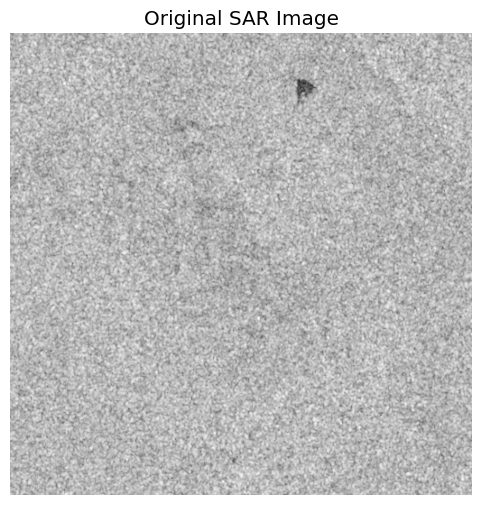

In [62]:
#visulaise original sar image
sample_key = valid_pairs[0]

with rasterio.open(sar_dict[sample_key]) as src:
    image = src.read(1)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")
plt.title("Original SAR Image")
plt.axis("off")
plt.show()

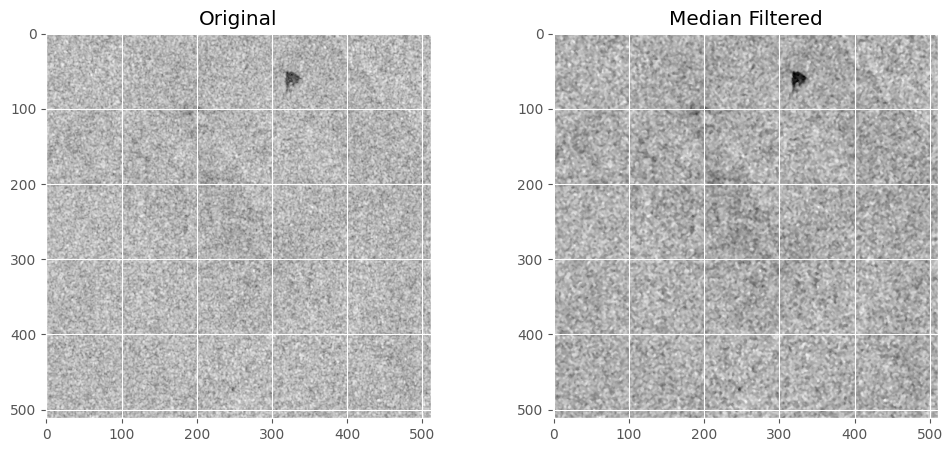

In [63]:
#SPECKLE NOISE REDUCTION
filtered_image = median_filter(image, size=3)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.subplot(1,2,2)
plt.imshow(filtered_image, cmap="gray")
plt.title("Median Filtered")
plt.show()

In [64]:
#NORMALIZATION
def normalize(img):
    img = img.astype(np.float32)
    return (
        img - np.min(img)
    ) / (
        np.max(img) - np.min(img) + 1e-8
    )

In [65]:
#EXAMPLE
normalized_image = normalize(filtered_image)

print(
    normalized_image.min(),
    normalized_image.max()
)

0.0 1.0


In [67]:
#RESIZE IMAGES
TARGET_SIZE = (128,128)
resized_image = resize(
    normalized_image,
    TARGET_SIZE,
    anti_aliasing=True
)

print(resized_image.shape)

(128, 128)


In [68]:
#DATA AUGMENTATION
def augment_image(img):
    augmented = []
    augmented.append(np.fliplr(img))
    augmented.append(np.flipud(img))
    augmented.append(np.rot90(img))
    return augmented

In [70]:
#EXAMPLE
augmented = augment_image(resized_image)
len(augmented)

3

In [71]:
#process entire dataset
processed_images = []
processed_masks = []
for key in valid_pairs:

    try:

        with rasterio.open(sar_dict[key]) as src:
            img = src.read(1)

        with rasterio.open(mask_dict[key]) as src:
            mask = src.read(1)

        img = median_filter(img,size=3)

        img = normalize(img)

        img = resize(
            img,
            TARGET_SIZE,
            anti_aliasing=True
        )

        mask = resize(
            mask,
            TARGET_SIZE,
            preserve_range=True,
            anti_aliasing=False
        )

        processed_images.append(img)
        processed_masks.append(mask)

    except:
        pass

In [72]:
#convert to numpy arrays
X = np.array(processed_images)
y = np.array(processed_masks)
print(X.shape)
print(y.shape)

(446, 128, 128)
(446, 128, 128)


In [73]:
#label encoding
binary_labels = []
for mask in y:
    flood_pixels = np.sum(mask > 0)
    if flood_pixels > 0:
        binary_labels.append("Flood")
    else:
        binary_labels.append("NoFlood")

In [74]:
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(
    binary_labels
)
print(
    encoder.classes_
)

['Flood' 'NoFlood']


In [75]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels
)
print(X_train.shape)
print(X_test.shape)

(356, 128, 128)
(90, 128, 128)


In [76]:
#autoencoder compression preparation
X_train_ae = np.expand_dims(
    X_train,
    axis=-1
)

X_test_ae = np.expand_dims(
    X_test,
    axis=-1
)

print(X_train_ae.shape)

(356, 128, 128, 1)


In [77]:
#save proccessed data
PROCESSED_DIR = "/content/drive/MyDrive/sar-project/data/processed"
os.makedirs(
    PROCESSED_DIR,
    exist_ok=True
)

In [78]:
#save arrays
np.save(
    f"{PROCESSED_DIR}/X_train.npy",
    X_train_ae
)

np.save(
    f"{PROCESSED_DIR}/X_test.npy",
    X_test_ae
)

np.save(
    f"{PROCESSED_DIR}/y_train.npy",
    y_train
)

np.save(
    f"{PROCESSED_DIR}/y_test.npy",
    y_test
)

these are direct inputs for notebook 3

In [79]:
print(os.listdir(PROCESSED_DIR))

['X_train.npy', 'X_test.npy', 'y_train.npy', 'y_test.npy']
